/tmp/ipykernel_1681971/781297918.py:25: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  Tx = sp.diags([1, -2, 1], [-1, 0, 1],
/tmp/ipykernel_1681971/781297918.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  Ty = sp.diags([1, -2, 1], [-1, 0, 1],


Ep   20 | Total 8.809e+00 | Data 1.733e+00 | Res 3.943e-01 | BC 6.682e+00 | LR 9.97e-04
Ep   40 | Total 1.003e+00 | Data 1.655e-01 | Res 2.049e-01 | BC 6.329e-01 | LR 9.89e-04
Ep   60 | Total 2.190e-01 | Data 7.273e-03 | Res 1.852e-01 | BC 2.658e-02 | LR 9.76e-04
Ep   80 | Total 1.782e-01 | Data 1.012e-03 | Res 1.681e-01 | BC 9.109e-03 | LR 9.57e-04
Ep  100 | Total 1.597e-01 | Data 8.326e-04 | Res 1.510e-01 | BC 7.927e-03 | LR 9.34e-04
Ep  120 | Total 1.444e-01 | Data 9.456e-04 | Res 1.357e-01 | BC 7.818e-03 | LR 9.05e-04
Ep  140 | Total 1.328e-01 | Data 1.107e-03 | Res 1.235e-01 | BC 8.197e-03 | LR 8.73e-04
Ep  160 | Total 1.224e-01 | Data 1.160e-03 | Res 1.130e-01 | BC 8.307e-03 | LR 8.36e-04
Ep  180 | Total 1.120e-01 | Data 1.126e-03 | Res 1.028e-01 | BC 8.069e-03 | LR 7.96e-04
Ep  200 | Total 1.015e-01 | Data 1.062e-03 | Res 9.278e-02 | BC 7.660e-03 | LR 7.52e-04
Ep  220 | Total 9.211e-02 | Data 1.016e-03 | Res 8.377e-02 | BC 7.327e-03 | LR 7.06e-04
Ep  240 | Total 8.346e-02 | Data

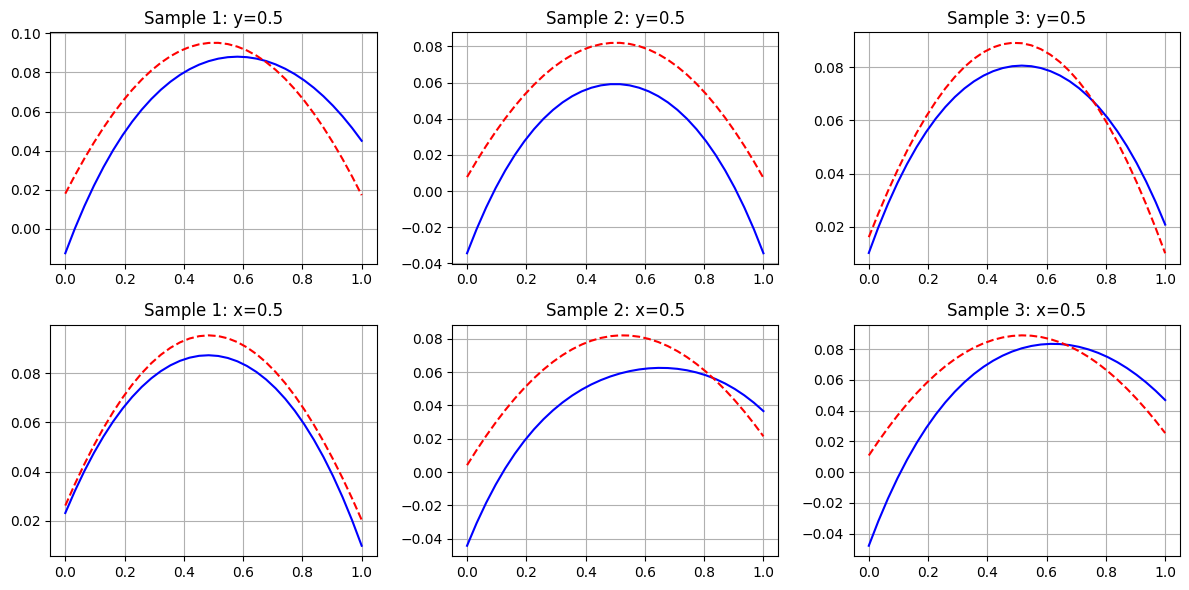

In [4]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ============================================================
# Utilities
# ============================================================

Nx = Ny = 32

def compute_2d_poisson(x, y, f, bc):
    Nx = len(x)
    Ny = len(y)

    hx = x[1] - x[0]
    hy = y[1] - y[0]

    Nxi = Nx - 2
    Nyi = Ny - 2

    # Correct discrete Laplacian for -Δu = f
    Tx = sp.diags([1, -2, 1], [-1, 0, 1],
                  shape=(Nxi, Nxi), format="csr") / hx**2
    Ty = sp.diags([1, -2, 1], [-1, 0, 1],
                  shape=(Nyi, Nyi), format="csr") / hy**2

    Ix = sp.eye(Nxi, format="csr")
    Iy = sp.eye(Nyi, format="csr")

    L = - (sp.kron(Iy, Tx) + sp.kron(Ty, Ix))

    b = f[1:-1,1:-1].copy()

    b[0,:]  += bc["left"][1:-1]   / hx**2
    b[-1,:] += bc["right"][1:-1]  / hx**2
    b[:,0]  += bc["bottom"][1:-1] / hy**2
    b[:,-1] += bc["top"][1:-1]    / hy**2

    b = b.reshape(-1)

    u_inner = spla.spsolve(L, b)

    u = np.zeros((Nx,Ny))
    u[1:-1,1:-1] = u_inner.reshape(Nxi,Nyi)

    u[0,:]  = bc["left"]
    u[-1,:] = bc["right"]
    u[:,0]  = bc["bottom"]
    u[:,-1] = bc["top"]

    return u


def boundary_loss(u, bc):
    return (
        ((u[:,0,:]  - bc["left"])**2).mean() +
        ((u[:,-1,:] - bc["right"])**2).mean() +
        ((u[:,:,0]  - bc["bottom"])**2).mean() +
        ((u[:,:,-1] - bc["top"])**2).mean()
    )

# FULL BC encoding
def bc_features(bc):
    return torch.cat([
        bc["left"],
        bc["right"],
        bc["bottom"],
        bc["top"],
    ], dim=1)

# ============================================================
# DeepONet
# ============================================================

class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(256,256)):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d,h), nn.Tanh()]
            d = h
        layers.append(nn.Linear(d,out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self,x):
        return self.net(x)

class DeepONet2D(nn.Module):
    def __init__(self, branch_dim, p=256):
        super().__init__()
        self.branch = MLP(branch_dim,p)
        self.trunk  = MLP(2,p)
        self.bias   = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, coords):
        b = self.branch(branch_input)
        t = self.trunk(coords)
        return (b[:,None,:]*t[None,:,:]).sum(-1) + self.bias

# ============================================================
# Trainer
# ============================================================

class Trainer:
    def __init__(self, model, coords, f, u, bc,
                 lr=1e-3, res_w=1.0, bc_w=1.0, device="cpu"):

        self.model = model.to(device)
        self.coords = coords.to(device).requires_grad_(True)
        self.f = torch.tensor(f, dtype=torch.float32, device=device)
        self.u = torch.tensor(u, dtype=torch.float32, device=device)
        self.bc = {k: torch.tensor(v, dtype=torch.float32, device=device)
                   for k,v in bc.items()}
        self.opt = torch.optim.Adam(model.parameters(), lr=lr)
        self.res_w = res_w
        self.bc_w  = bc_w
        self.B = f.shape[0]

    def laplacian(self, u):
        g = torch.autograd.grad(u, self.coords,
                                torch.ones_like(u), create_graph=True)[0]
        ux, uy = g[:,0], g[:,1]

        uxx = torch.autograd.grad(ux, self.coords,
                                  torch.ones_like(ux), create_graph=True)[0][:,0]
        uyy = torch.autograd.grad(uy, self.coords,
                                  torch.ones_like(uy), create_graph=True)[0][:,1]
        return uxx + uyy

    def train(self, epochs=600):
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.opt, T_max=epochs, eta_min=1e-5
        )

        for ep in range(1,epochs+1):

            self.opt.zero_grad()

            branch = torch.cat([self.f, bc_features(self.bc)], dim=1)
            up = self.model(branch, self.coords)

            data_loss = ((up - self.u)**2).mean()

            res = 0.0
            for i in range(self.B):
                r = -self.laplacian(up[i]) - self.f[i]
                res += (r**2).mean()
            res /= self.B

            bc_l = boundary_loss(up.view(self.B,Nx,Ny), self.bc)

            loss = data_loss + self.res_w*res + self.bc_w*bc_l

            loss.backward()
            self.opt.step()
            scheduler.step()

            if ep % 20 == 0:
                print(f"Ep {ep:4d} | Total {loss.item():.3e} | "
                      f"Data {data_loss.item():.3e} | "
                      f"Res {res.item():.3e} | "
                      f"BC {bc_l.item():.3e} | "
                      f"LR {self.opt.param_groups[0]['lr']:.2e}")

# ============================================================
# Main
# ============================================================

np.random.seed(0)
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

x = np.linspace(0,1,Nx)
y = np.linspace(0,1,Ny)
X,Y = np.meshgrid(x,y,indexing="ij")
coords = torch.tensor(np.c_[X.ravel(),Y.ravel()], dtype=torch.float32)

N = 300
f_all, u_all = [], []
bc_all = {"left":[], "right":[], "bottom":[], "top":[]}

for _ in range(N):

    # Vary forcing magnitude
    f_val = np.random.uniform(0.5, 2.0)
    f = f_val * np.ones((Nx, Ny))

    # Small smooth boundary perturbation
    eps = 0.05  # strength of randomness

    # Random amplitudes for each side
    a_left   = np.random.uniform(-1,1)
    a_right  = np.random.uniform(-1,1)
    a_bottom = np.random.uniform(-1,1)
    a_top    = np.random.uniform(-1,1)

    # Smooth low-frequency profiles (zero at corners)
    left_profile   = eps * a_left   * np.sin(np.pi * y)
    right_profile  = eps * a_right  * np.sin(np.pi * y)
    bottom_profile = eps * a_bottom * np.sin(np.pi * x)
    top_profile    = eps * a_top    * np.sin(np.pi * x)

    bc = {
        "left":   left_profile,
        "right":  right_profile,
        "bottom": bottom_profile,
        "top":    top_profile,
    }

    u = compute_2d_poisson(x, y, f, bc)

    f_all.append(f.ravel())
    u_all.append(u.ravel())

    for k in bc:
        bc_all[k].append(bc[k])

f_all = np.array(f_all)
u_all = np.array(u_all)



# FULL BC input
model = DeepONet2D(branch_dim=Nx*Ny + 4*Nx, p=512)
trainer = Trainer(model, coords, f_all, u_all, bc_all,
                  lr=1e-3, res_w=1.0, bc_w=1.0, device=device)
trainer.train(epochs=600)

# ============================================================
# Test
# ============================================================

np.random.seed(42)
n_test_samples = 3
slice_idx = Nx // 2

fig, axes = plt.subplots(2, n_test_samples, figsize=(4*n_test_samples, 6))

for col in range(n_test_samples):

    f_test = np.ones((Nx, Ny))

    eps = 0.05

    left_profile   = eps * np.sin(np.pi * y) * np.random.uniform(-1,1)
    right_profile  = eps * np.sin(np.pi * y) * np.random.uniform(-1,1)
    bottom_profile = eps * np.sin(np.pi * x) * np.random.uniform(-1,1)
    top_profile    = eps * np.sin(np.pi * x) * np.random.uniform(-1,1)

    bc_test = {
        "left":   left_profile,
        "right":  right_profile,
        "bottom": bottom_profile,
        "top":    top_profile,
    }

    u_true = compute_2d_poisson(x, y, f_test, bc_test) 

    bc_test_norm = {k: v  for k, v in bc_test.items()}

    with torch.no_grad():

        f_flat = torch.tensor(f_test.ravel()[None,:],
                              dtype=torch.float32, device=device)

        bc_flat = torch.tensor(np.concatenate([
            bc_test_norm["left"],
            bc_test_norm["right"],
            bc_test_norm["bottom"],
            bc_test_norm["top"]
        ])[None,:], dtype=torch.float32, device=device)

        branch_input = torch.cat([f_flat, bc_flat], 1)

        u_pred = model(branch_input, coords.to(device))
        u_pred = u_pred.cpu().numpy().reshape(Nx, Ny)

    axes[0,col].plot(x, u_true[:, slice_idx], 'b', label='True')
    axes[0,col].plot(x, u_pred[:, slice_idx], 'r--', label='DeepONet')
    axes[0,col].set_title(f'Sample {col+1}: y=0.5')
    axes[0,col].grid()

    axes[1,col].plot(y, u_true[slice_idx, :], 'b', label='True')
    axes[1,col].plot(y, u_pred[slice_idx, :], 'r--', label='DeepONet')
    axes[1,col].set_title(f'Sample {col+1}: x=0.5')
    axes[1,col].grid()

plt.tight_layout()
plt.show()
